<a href="https://colab.research.google.com/github/matteo2911/Computer-Graphics/blob/main/partial_finetune4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SAM 3 - Partial Fine-Tune v4 (loss anti-mancanze + augmentation mirata + TTA)

Notebook autosufficiente, derivato da partial_finetune (v1/v3). La parte di
**collegamento esterno e I/O resta identica** a v1/v2 (install, login HF/W&B, mount Drive,
download Roboflow, verifica dataset, sanity check zero-shot). Cambia **solo l'addestramento**.

## Cosa cambia rispetto a v1/v2/v3
Gli overlay di v1/v2 mostrano che l'errore dominante e' la **sotto-segmentazione (mancanze)**
su **cartelloni neri/scuri** e **lontani / seconda fila**. Quasi nessun falso positivo.
Quindi v4 introduce:

1. **Loss anti-mancanze**: BCE con pos_weight (~8) + **Focal-Tversky** con beta > alpha
   (penalizza i falsi negativi piu' dei falsi positivi).
2. **Augmentation mirata sul train** (nel dataloader, niente nuove dipendenze):
   brightness/contrast/gamma verso il basso (simula board scuri/notturni) + zoom-out
   (simula board lontani/seconda fila) + horizontal flip.
3. **Test-Time Augmentation (hflip)** in eval, applicata uguale su val e test.
4. **Threshold sweep su VALIDATION** (come v3) -> niente data leakage.

Sblocco pesi invariato: solo mask_decoder (2.3M, 0.27%).

## Prerequisiti
1. Runtime GPU.
2. Secrets (icona chiave): HF_TOKEN, ROBOFLOW_API_KEY. W&B key hardcoded in cella 3.
3. Versione Roboflow generata (COCO Segmentation, resize 1008x1008).
4. Drive montato dalla prima cella.


## 1. Install + login + mount Drive

In [1]:
!pip install -q transformers>=4.46 accelerate roboflow pycocotools tqdm wandb

In [2]:
import os, json, math, random, pathlib, yaml
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from PIL import Image
from tqdm.auto import tqdm

from google.colab import drive, userdata
from huggingface_hub import login
import wandb

drive.mount('/content/drive')
login(token=userdata.get('HF_TOKEN'))

  # --- W&B ---
WANDB_KEY = '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'

if WANDB_KEY:
    os.environ['WANDB_API_KEY'] = WANDB_KEY
    wandb.login()
    print('W&B login OK')
else:
    print('⚠️  W&B disabilitato')

DRIVE = pathlib.Path('/content/drive/MyDrive/addestramento')
for sub in ('data/billboards', 'outputs/checkpoints', 'logs', 'hf_cache'):
    (DRIVE / sub).mkdir(parents=True, exist_ok=True)
os.environ['HF_HOME'] = str(DRIVE / 'hf_cache')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device, '| GPU:', torch.cuda.get_device_name(0) if device=='cuda' else 'none')


Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: mat-romeo (mat-romeo-roma-tre) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B login OK
Device: cuda | GPU: NVIDIA L4


## 2. Iperparametri (modifica qui i tuoi valori)

In [3]:
CFG = dict(
    # --- ROBOFLOW ---
    rf_workspace = 'ciao-3wtnr',
    rf_project   = 'sam3-annotation',
    rf_version   = 2,                 # <- AGGIORNA al numero della nuova Version quando rigeneri il dataset

    # --- MODELLO ---
    model_id     = 'facebook/sam3',
    prompt_text  = 'billboard',

    # --- TRAINING (invariato rispetto a v1/v3) ---
    train_image_size = 1008,
    eval_image_size  = 1008,
    batch_size       = 4,
    grad_accum_steps = 1,
    num_epochs       = 20,
    lr               = 1e-4,
    weight_decay     = 0.01,
    warmup_steps     = 50,
    early_stop_pat   = 5,
    seed             = 42,

    # --- LOSS anti-mancanze (novita' v4) ---
    bce_weight    = 1.0,
    ftv_weight    = 1.0,
    pos_weight    = 8.0,       # peso pixel 'cartellone' nella BCE (sbilanciamento board/sfondo)
    tversky_alpha = 0.3,       # peso falsi positivi
    tversky_beta  = 0.7,       # peso falsi negativi (MANCANZE) > alpha
    tversky_gamma = 1.3333,    # focal (concentra sui casi difficili)

    # --- AUGMENTATION mirata sul train (novita' v4) ---
    use_augment = True,

    # --- EVAL: TTA + threshold sweep su VAL (novita' v4 + v3) ---
    use_tta = True,
    threshold_sweep_range = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60],

    # --- W&B ---
    wandb_project    = 'sam3-billboards',
    wandb_run_name   = 'partial-ft-v4-ftversky-aug-tta',

    # --- PATHS (file separati per non sovrascrivere i checkpoint precedenti) ---
    data_root  = str(DRIVE / 'data' / 'billboards_v2'),
    ckpt_path  = str(DRIVE / 'outputs' / 'checkpoints' / 'mask_decoder_v4.pt'),
)

random.seed(CFG['seed']); np.random.seed(CFG['seed']); torch.manual_seed(CFG['seed'])
print(json.dumps({k: v for k, v in CFG.items() if not k.startswith('rf_')}, indent=2, default=str))


{
  "model_id": "facebook/sam3",
  "prompt_text": "billboard",
  "train_image_size": 1008,
  "eval_image_size": 1008,
  "batch_size": 4,
  "grad_accum_steps": 1,
  "num_epochs": 20,
  "lr": 0.0001,
  "weight_decay": 0.01,
  "warmup_steps": 50,
  "early_stop_pat": 5,
  "seed": 42,
  "bce_weight": 1.0,
  "ftv_weight": 1.0,
  "pos_weight": 8.0,
  "tversky_alpha": 0.3,
  "tversky_beta": 0.7,
  "tversky_gamma": 1.3333,
  "use_augment": true,
  "use_tta": true,
  "threshold_sweep_range": [
    0.3,
    0.35,
    0.4,
    0.45,
    0.5,
    0.55,
    0.6
  ],
  "wandb_project": "sam3-billboards",
  "wandb_run_name": "partial-ft-v4-ftversky-aug-tta",
  "data_root": "/content/drive/MyDrive/addestramento/data/billboards_v2",
  "ckpt_path": "/content/drive/MyDrive/addestramento/outputs/checkpoints/mask_decoder_v4.pt"
}


## 3. Download dataset da Roboflow
Esporta automaticamente in formato **COCO Segmentation** dentro `data/billboards/{train,valid,test}/`.

In [4]:
# Install roboflow se manca (succede dopo riavvio runtime)
import importlib
try:
    importlib.import_module('roboflow')
except ImportError:
    !pip install -q roboflow
import pathlib
from google.colab import userdata
from roboflow import Roboflow

  # Verifica config
if not all([CFG['rf_workspace'], CFG['rf_project']]):
    raise RuntimeError("Compila rf_workspace, rf_project, rf_version nella cella CONFIG.")

  # Salta il download se il dataset è già su Drive
data_root = pathlib.Path(CFG['data_root'])
data_root.mkdir(parents=True, exist_ok=True)

if (data_root / 'train' / '_annotations.coco.json').exists():
    print(f'✅ Dataset già presente in {data_root}, salto il download.')
else:
    rf = Roboflow(api_key=userdata.get('ROBOFLOW_API_KEY'))
    ds = (rf.workspace(CFG['rf_workspace'])
            .project(CFG['rf_project'])
            .version(CFG['rf_version'])
            .download('coco-segmentation', location=str(data_root)))
    print(f'✅ Dataset scaricato in: {ds.location}')

  # Struttura finale
print('\nContenuto:')
for p in sorted(data_root.iterdir()):
    if p.is_dir():
        n = len(list(p.iterdir()))
        print(f'  📁 {p.name}/ ({n} file)')




✅ Dataset già presente in /content/drive/MyDrive/addestramento/data/billboards_v2, salto il download.

Contenuto:
  📁 test/ (34 file)
  📁 train/ (466 file)
  📁 valid/ (34 file)


## 4. Verifica dataset (immagini, annotazioni, classi)

In [5]:
from pycocotools.coco import COCO

for split in ['train', 'valid', 'test']:
    p = pathlib.Path(CFG['data_root']) / split / '_annotations.coco.json'
    if not p.exists():
        print(f'[!] {split}: manca {p}'); continue
    coco = COCO(str(p))
    cats = {c['id']: c['name'] for c in coco.dataset['categories']}
    print(f"{split:5s} | imgs={len(coco.imgs)} | anns={len(coco.anns)} | cats={cats}")

loading annotations into memory...
Done (t=0.97s)
creating index...
index created!
train | imgs=465 | anns=1104 | cats={0: 'objects', 1: 'billboard', 2: 'objects'}
loading annotations into memory...
Done (t=0.85s)
creating index...
index created!
valid | imgs=33 | anns=76 | cats={0: 'objects', 1: 'billboard', 2: 'objects'}
loading annotations into memory...
Done (t=0.93s)
creating index...
index created!
test  | imgs=33 | anns=71 | cats={0: 'objects', 1: 'billboard', 2: 'objects'}


## 5. Sanity check zero-shot: SAM 3 base sa già segmentare i cartelloni?
Predizione su un'immagine random del test, **prima** di addestrare. Se zero-shot fa già un buon lavoro, il fine-tune migliora ulteriormente; se sbaglia parecchio, hai motivo concreto per fare partial-FT.

processor_config.json:   0%|          | 0.00/1.71k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/799 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.64M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Pesi base caricati. Param totali: 840.376374 M
Immagine campione: test031_png.rf.8f3892351c6310592548b4d74199a6e9.jpg
Trovate 7 istanze zero-shot


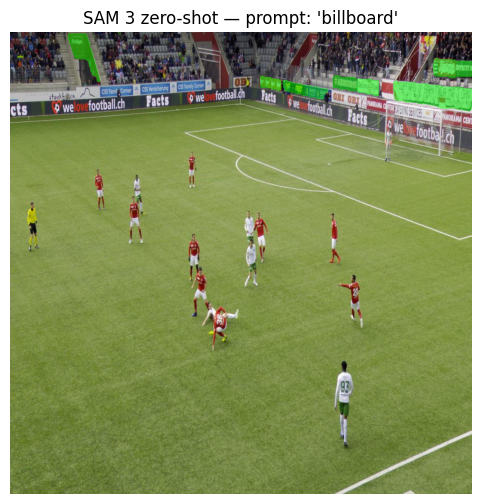

In [6]:
import matplotlib.pyplot as plt
from transformers import Sam3Model, Sam3Processor

processor = Sam3Processor.from_pretrained(CFG['model_id'])
base_model = Sam3Model.from_pretrained(CFG['model_id'], device_map='auto', torch_dtype='auto').eval()
print('Pesi base caricati. Param totali:', sum(p.numel() for p in base_model.parameters())/1e6, 'M')

test_dir = pathlib.Path(CFG['data_root']) / 'test'
imgs = [p for p in test_dir.iterdir() if p.suffix.lower() in {'.jpg','.jpeg','.png'}]
sample = random.choice(imgs); print('Immagine campione:', sample.name)
image = Image.open(sample).convert('RGB')

inputs = processor(images=image, text=CFG['prompt_text'], return_tensors='pt').to(base_model.device)
with torch.no_grad():
    outputs = base_model(**inputs)
results = processor.post_process_instance_segmentation(
    outputs, threshold=0.5, mask_threshold=0.5,
    target_sizes=inputs.get('original_sizes').tolist(),
)[0]
print(f"Trovate {len(results['masks'])} istanze zero-shot")

overlay = np.array(image).copy()
for m in results['masks']:
    m = m.cpu().numpy().astype(bool)
    overlay[m] = (0.5*overlay[m] + 0.5*np.array([0,255,0])).astype(np.uint8)
plt.figure(figsize=(10,6)); plt.imshow(overlay); plt.axis('off')
plt.title(f"SAM 3 zero-shot — prompt: '{CFG['prompt_text']}'"); plt.show()

del base_model; torch.cuda.empty_cache()  # libera memoria, ricarichiamo per il training

## 6. Dataset PyTorch (con augmentation mirata sul train)
Per ogni immagine fondiamo tutte le maschere delle istanze in un'unica maschera binaria
(target per la loss su semantic_seg). **Novita' v4**: sul solo train applichiamo augmentation
che simula i casi dove il modello sbaglia (board scuri -> brightness/gamma giu'; board lontani
-> zoom-out; + horizontal flip). Implementata senza nuove dipendenze.


In [7]:
import random as _random

def augment_pair(img, mask, s):
    """img: uint8 HxWx3 ; mask: uint8 HxW (0/1). Augmentation mirata ai fallimenti del modello.
    Usa il modulo random (che PyTorch ri-seeda per ogni worker) per evitare augmentation
    duplicate tra i worker del DataLoader."""
    # 1) horizontal flip
    if _random.random() < 0.5:
        img = img[:, ::-1, :].copy(); mask = mask[:, ::-1].copy()
    # 2) zoom-out: scala l'immagine a fattore f e la incolla su canvas s x s (board piu' piccoli/lontani)
    if _random.random() < 0.5:
        f = _random.uniform(0.6, 1.0)
        ns = max(8, int(s * f))
        im_s = np.asarray(Image.fromarray(img).resize((ns, ns), Image.BILINEAR))
        mk_s = np.asarray(Image.fromarray((mask * 255).astype(np.uint8)).resize((ns, ns), Image.NEAREST)) // 255
        ci = np.zeros((s, s, 3), np.uint8); cm = np.zeros((s, s), np.uint8)
        oy = _random.randint(0, s - ns); ox = _random.randint(0, s - ns)
        ci[oy:oy + ns, ox:ox + ns] = im_s; cm[oy:oy + ns, ox:ox + ns] = mk_s
        img, mask = ci, cm
    # 3) fotometriche (solo immagine): simula board scuri/notturni
    f = img.astype(np.float32)
    if _random.random() < 0.7:                       # brightness (bias verso il piu' scuro)
        f *= _random.uniform(0.5, 1.1)
    if _random.random() < 0.5:                       # contrast
        mu = f.mean(); f = (f - mu) * _random.uniform(0.7, 1.3) + mu
    if _random.random() < 0.5:                       # gamma
        g = _random.uniform(0.7, 1.4); f = 255.0 * np.clip(f / 255.0, 0, 1) ** g
    img = np.clip(f, 0, 255).astype(np.uint8)
    return img, mask


class BillboardDataset(Dataset):
    def __init__(self, split_dir: pathlib.Path, image_size: int, augment: bool = False):
        self.split_dir = split_dir
        self.image_size = image_size
        self.augment = augment
        self.coco = COCO(str(split_dir / '_annotations.coco.json'))
        self.img_ids = self.coco.getImgIds()

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        info = self.coco.loadImgs([img_id])[0]
        img = Image.open(self.split_dir / info['file_name']).convert('RGB')

        h, w = info['height'], info['width']
        union = np.zeros((h, w), dtype=np.uint8)
        for ann in self.coco.loadAnns(self.coco.getAnnIds(imgIds=img_id)):
            union |= self.coco.annToMask(ann).astype(np.uint8)

        s = self.image_size
        img = np.asarray(img.resize((s, s), Image.BILINEAR))
        mask = np.asarray(Image.fromarray(union * 255).resize((s, s), Image.NEAREST)) // 255  # 0/1 uint8

        if self.augment:
            img, mask = augment_pair(img, mask, s)

        return Image.fromarray(img), mask.astype(np.float32)


train_ds = BillboardDataset(pathlib.Path(CFG['data_root']) / 'train', CFG['train_image_size'], augment=CFG['use_augment'])
valid_ds = BillboardDataset(pathlib.Path(CFG['data_root']) / 'valid', CFG['train_image_size'], augment=False)
print(f"Train: {len(train_ds)} (augment={CFG['use_augment']}) | Valid: {len(valid_ds)}")


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Train: 465 (augment=True) | Valid: 33


## 7. Carica modello e applica partial fine-tune
Congeliamo tutto, sblocchiamo solo i parametri il cui nome contiene `mask_decoder`.

In [8]:
processor = Sam3Processor.from_pretrained(
    CFG['model_id'],
    size={'height': CFG['train_image_size'], 'width': CFG['train_image_size']},
)
model = Sam3Model.from_pretrained(CFG['model_id'], torch_dtype=torch.float32).to(device)

# 1) freeza tutto
for p in model.parameters():
    p.requires_grad = False
# 2) sblocca solo il mask decoder
trainable, total = 0, 0
for name, p in model.named_parameters():
    total += p.numel()
    if 'mask_decoder' in name:
        p.requires_grad = True
        trainable += p.numel()
print(f'Trainable: {trainable/1e6:.2f}M / Total: {total/1e6:.2f}M ({100*trainable/total:.2f}%)')

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Trainable: 2.30M / Total: 840.38M (0.27%)


## 8. Collate, DataLoader, loss anti-mancanze (BCE pos_weight + Focal-Tversky)
La loss penalizza i **falsi negativi** (mancanze, il nostro errore) piu' dei falsi positivi:
pos_weight alza il peso dei pixel 'cartellone' nella BCE, e la Focal-Tversky con beta>alpha
fa lo stesso sul termine di overlap.


In [9]:
PROMPT = CFG['prompt_text']
def collate(batch):
    images, masks = zip(*batch)
    inputs = processor(images=list(images), text=[PROMPT] * len(images), return_tensors='pt')
    masks = torch.from_numpy(np.stack(masks))
    return inputs, masks

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                          collate_fn=collate, num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=CFG['batch_size'], shuffle=False,
                          collate_fn=collate, num_workers=2, pin_memory=True)

_pos_weight = torch.tensor(float(CFG['pos_weight']), device=device)

def focal_tversky(prob, target, alpha, beta, gamma, eps=1e-6):
    p, t = prob.flatten(1), target.flatten(1)
    tp = (p * t).sum(1)
    fp = (p * (1 - t)).sum(1)
    fn = ((1 - p) * t).sum(1)
    tversky = (tp + eps) / (tp + alpha * fp + beta * fn + eps)
    return (1 - tversky) ** gamma            # per-sample

def seg_loss(logits_bhw, target_bhw):
    bce = F.binary_cross_entropy_with_logits(
        logits_bhw, target_bhw, pos_weight=_pos_weight, reduction='none').mean([1, 2])
    ftv = focal_tversky(torch.sigmoid(logits_bhw), target_bhw,
                        CFG['tversky_alpha'], CFG['tversky_beta'], CFG['tversky_gamma'])
    loss = (CFG['bce_weight'] * bce + CFG['ftv_weight'] * ftv).mean()
    return loss, bce.mean().item(), ftv.mean().item()


## 9. Training loop con mixed precision, grad accum, early stopping

In [10]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = AdamW(params, lr=CFG['lr'], weight_decay=CFG['weight_decay'])

total_steps = math.ceil(len(train_loader) / CFG['grad_accum_steps']) * CFG['num_epochs']
warmup = CFG['warmup_steps']
def lr_lambda(step):
    if step < warmup: return step / max(1, warmup)
    p = (step - warmup) / max(1, total_steps - warmup)
    return 0.5 * (1 + math.cos(math.pi * p))
scheduler = LambdaLR(optimizer, lr_lambda)

# bf16 su L4/A100, fp16 su T4 (T4 non supporta bf16)
amp_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
use_scaler = (amp_dtype == torch.float16)
scaler = torch.amp.GradScaler('cuda', enabled=use_scaler)
print('AMP dtype:', amp_dtype)

wandb.init(
    project=CFG['wandb_project'],
    name=CFG['wandb_run_name'],
    config={k: v for k, v in CFG.items() if k not in {'rf_workspace', 'rf_project'}},
    tags=['sam3', 'partial-ft', 'v4', 'focal-tversky', 'aug', 'tta'],
)
wandb.config.update({'amp_dtype': str(amp_dtype), 'gpu': torch.cuda.get_device_name(0)})

@torch.no_grad()
def evaluate(loader):
    model.eval()
    ious = []
    for inputs, masks in loader:
        inputs = inputs.to(device); masks = masks.to(device)
        with torch.autocast('cuda', dtype=amp_dtype):
            out = model(**inputs)
        logits = F.interpolate(out.semantic_seg.float(), size=masks.shape[-2:],
                                mode='bilinear', align_corners=False).squeeze(1)
        pred = (torch.sigmoid(logits) > 0.5).float()
        inter = (pred * masks).sum([1, 2])
        union = ((pred + masks) > 0).float().sum([1, 2])
        ious.extend(((inter + 1e-6) / (union + 1e-6)).cpu().tolist())
    return float(np.mean(ious))

best_miou, patience = -1.0, 0
history = {'epoch': [], 'train_loss': [], 'val_miou': []}
global_step = 0
LOG_EVERY = 10

for epoch in range(CFG['num_epochs']):
    model.train()
    pbar = tqdm(train_loader, desc=f"epoch {epoch+1}/{CFG['num_epochs']}")
    optimizer.zero_grad()
    running, n = 0.0, 0
    for step, (inputs, masks) in enumerate(pbar):
        inputs = inputs.to(device); masks = masks.to(device)
        with torch.autocast('cuda', dtype=amp_dtype):
            out = model(**inputs)
            logits = F.interpolate(out.semantic_seg, size=masks.shape[-2:],
                                    mode='bilinear', align_corners=False).squeeze(1)
            loss, bce, ftv = seg_loss(logits, masks)
            loss_scaled = loss / CFG['grad_accum_steps']
        if use_scaler:
            scaler.scale(loss_scaled).backward()
        else:
            loss_scaled.backward()
        if (step + 1) % CFG['grad_accum_steps'] == 0:
            if use_scaler:
                scaler.step(optimizer); scaler.update()
            else:
                optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
        running += loss.item(); n += 1; global_step += 1
        pbar.set_postfix(loss=f'{running/n:.4f}', bce=f'{bce:.3f}', ftv=f'{ftv:.3f}')
        if global_step % LOG_EVERY == 0:
            wandb.log({'train/loss': loss.item(), 'train/bce': bce, 'train/focal_tversky': ftv,
                       'train/lr': scheduler.get_last_lr()[0], 'epoch': epoch + 1}, step=global_step)

    # --- fine epoca: validation + checkpoint + early stopping ---
    val_miou = evaluate(valid_loader)
    train_loss = running / max(1, n)
    history['epoch'].append(epoch + 1)
    history['train_loss'].append(train_loss)
    history['val_miou'].append(val_miou)
    print(f'  epoch {epoch+1}: train_loss={train_loss:.4f} | val mIoU: {val_miou:.4f}')
    wandb.log({'val/mIoU': val_miou, 'train/epoch_loss': train_loss, 'epoch': epoch + 1}, step=global_step)

    if val_miou > best_miou:
        best_miou = val_miou; patience = 0
        sd = {k: v.cpu() for k, v in model.state_dict().items() if 'mask_decoder' in k}
        torch.save(sd, CFG['ckpt_path'])
        print(f"    nuovo best (mIoU={best_miou:.4f}) salvato in {CFG['ckpt_path']}")
    else:
        patience += 1
        if patience >= CFG['early_stop_pat']:
            print(f'    early stop a epoch {epoch+1} (best val mIoU={best_miou:.4f})')
            break

print(f'\nBest val mIoU: {best_miou:.4f}')
wandb.summary['best_val_miou'] = best_miou


AMP dtype: torch.bfloat16


epoch 1/20:   0%|          | 0/117 [00:00<?, ?it/s]

  epoch 1: train_loss=0.2449 | val mIoU: 0.7665
    nuovo best (mIoU=0.7665) salvato in /content/drive/MyDrive/addestramento/outputs/checkpoints/mask_decoder_v4.pt


epoch 2/20:   0%|          | 0/117 [00:00<?, ?it/s]

  epoch 2: train_loss=0.0683 | val mIoU: 0.8090
    nuovo best (mIoU=0.8090) salvato in /content/drive/MyDrive/addestramento/outputs/checkpoints/mask_decoder_v4.pt


...

  epoch 17: train_loss=0.0272 | val mIoU: 0.8815


epoch 18/20:   0%|          | 0/117 [00:00<?, ?it/s]

  epoch 18: train_loss=0.0268 | val mIoU: 0.8807


epoch 19/20:   0%|          | 0/117 [00:20<?, ?it/s]

  epoch 19: train_loss=0.0263 | val mIoU: 0.8822
    early stop a epoch 19 (best val mIoU=0.8826)

Best val mIoU: 0.8826


## 10. Plot training history

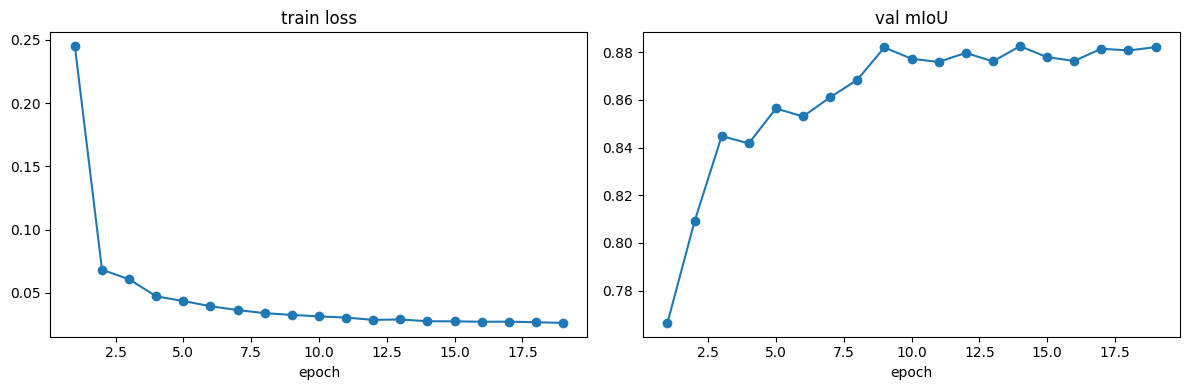

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history['epoch'], history['train_loss'], 'o-'); ax[0].set_title('train loss'); ax[0].set_xlabel('epoch')
ax[1].plot(history['epoch'], history['val_miou'], 'o-');   ax[1].set_title('val mIoU');   ax[1].set_xlabel('epoch')
plt.tight_layout(); plt.show()

## 11. Eval finale: TTA + threshold sweep su VAL -> applicazione su TEST

Procedura corretta (niente data leakage):
1. Probabilita' sul **validation** (con **TTA hflip** se attivo) -> sweep threshold -> best_thr
   per max val_mIoU.
2. Probabilita' sul **test** (stessa TTA) -> applico best_thr -> metriche finali.

Il modello base zero-shot e' valutato a soglia 0.5 senza TTA, solo per confronto.


In [12]:
# ===== EVAL FINALE: TTA + threshold sweep su VAL, applicazione al TEST =====
EVAL = CFG['eval_image_size']
processor_eval = Sam3Processor.from_pretrained(CFG['model_id'], size={'height': EVAL, 'width': EVAL})

# 1) base (confronto zero-shot)  2) fine-tuned (base + pesi mask_decoder salvati)
base_model = Sam3Model.from_pretrained(CFG['model_id'], device_map='auto', torch_dtype='auto').eval()
ft_model = Sam3Model.from_pretrained(CFG['model_id'], device_map='auto', torch_dtype='auto')
missing, unexpected = ft_model.load_state_dict(torch.load(CFG['ckpt_path'], map_location='cpu'), strict=False)
print(f'Pesi mask_decoder caricati. unexpected={len(unexpected)} (deve essere 0)')
ft_model.eval()

def gt_union_coco(coco_obj, img_id):
    info = coco_obj.loadImgs([img_id])[0]
    h, w = info['height'], info['width']
    union = np.zeros((h, w), dtype=bool)
    for ann in coco_obj.loadAnns(coco_obj.getAnnIds(imgIds=img_id)):
        union |= coco_obj.annToMask(ann).astype(bool)
    return union, info['file_name'], (h, w)

def iou(a, b):
    inter = np.logical_and(a, b).sum()
    uni = np.logical_or(a, b).sum()
    return float(inter / uni) if uni else 0.0

@torch.no_grad()
def get_probs(mdl, img, hw, tta=False):
    def _one(image):
        inputs = processor_eval(images=image, text=PROMPT, return_tensors='pt').to(mdl.device)
        out = mdl(**inputs)
        logits = F.interpolate(out.semantic_seg.float(), size=hw, mode='bilinear', align_corners=False).squeeze(1)
        return torch.sigmoid(logits[0]).cpu().numpy()
    p = _one(img)
    if tta:                                   # media con il flip orizzontale
        p_f = _one(img.transpose(Image.FLIP_LEFT_RIGHT))[:, ::-1]
        p = (p + p_f) / 2.0
    return p

TTA = CFG['use_tta']

# ----- FASE 1: sweep sul VALIDATION -----
print(f'\n=== FASE 1: threshold sweep sul VALIDATION (TTA={TTA}) ===')
valid_dir = pathlib.Path(CFG['data_root']) / 'valid'
coco_valid = COCO(str(valid_dir / '_annotations.coco.json'))
val_data = []
for img_id in tqdm(coco_valid.getImgIds(), desc='val probs (ft)'):
    gt, fname, hw = gt_union_coco(coco_valid, img_id)
    img = Image.open(valid_dir / fname).convert('RGB')
    val_data.append((get_probs(ft_model, img, hw, tta=TTA), gt))

THRESHOLDS = CFG['threshold_sweep_range']
val_results = {}
for thr in THRESHOLDS:
    ious_thr = [iou(gt, probs > thr) for probs, gt in val_data]
    val_results[thr] = {'mIoU': float(np.mean(ious_thr)),
                        'IoU@0.5':  float(np.mean([i >= 0.5  for i in ious_thr])),
                        'IoU@0.75': float(np.mean([i >= 0.75 for i in ious_thr])),
                        'IoU@0.9':  float(np.mean([i >= 0.9  for i in ious_thr]))}
best_thr = max(val_results, key=lambda k: val_results[k]['mIoU'])
hdr = '{:>6s} | {:>10s} | {:>9s} | {:>10s} | {:>9s}'.format('thr', 'val_mIoU', 'IoU@0.5', 'IoU@0.75', 'IoU@0.9')
print('\n' + hdr)
print('-' * 56)
for thr, r in val_results.items():
    marker = ' <- best' if thr == best_thr else ''
    print('{:>6.2f} | {:>10.4f} | {:>9.4f} | {:>10.4f} | {:>9.4f}{}'.format(
        thr, r['mIoU'], r['IoU@0.5'], r['IoU@0.75'], r['IoU@0.9'], marker))
print(f"\nBest threshold (scelto su VAL): {best_thr} -> val_mIoU = {val_results[best_thr]['mIoU']:.4f}")

# ----- FASE 2: applico best_thr al TEST -----
print('\n=== FASE 2: eval sul TEST con best_thr ===')
test_dir = pathlib.Path(CFG['data_root']) / 'test'
coco_test = COCO(str(test_dir / '_annotations.coco.json'))
ft_probs_cache, ft_ious, base_ious = [], [], []
for img_id in tqdm(coco_test.getImgIds(), desc='test eval (ft + base)'):
    gt, fname, hw = gt_union_coco(coco_test, img_id)
    img = Image.open(test_dir / fname).convert('RGB')
    probs_ft = get_probs(ft_model, img, hw, tta=TTA)
    probs_base = get_probs(base_model, img, hw, tta=False)
    ft_probs_cache.append((probs_ft, gt, fname))
    ft_ious.append(iou(gt, probs_ft > best_thr))
    base_ious.append(iou(gt, probs_base > 0.5))

m = {'best_threshold':          float(best_thr),
     'val_mIoU_at_best_thr':    float(val_results[best_thr]['mIoU']),
     'test/mIoU_ft':            float(np.mean(ft_ious)),
     'test/mIoU_base_zeroshot': float(np.mean(base_ious)),
     'test/delta':              float(np.mean(ft_ious) - np.mean(base_ious)),
     'test/IoU@0.5_ft':         float(np.mean([i >= 0.5  for i in ft_ious])),
     'test/IoU@0.75_ft':        float(np.mean([i >= 0.75 for i in ft_ious])),
     'test/IoU@0.9_ft':         float(np.mean([i >= 0.9  for i in ft_ious]))}
print('\n=== RISULTATI TEST ===')
for k, v in m.items(): print(f'  {k:30s}: {v:.4f}')
for k, v in m.items(): wandb.summary[k] = v


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Pesi mask_decoder caricati. unexpected=0 (deve essere 0)

=== FASE 1: threshold sweep sul VALIDATION (TTA=True) ===
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


val probs (ft):   0%|          | 0/33 [00:00<?, ?it/s]


   thr |   val_mIoU |   IoU@0.5 |   IoU@0.75 |   IoU@0.9
--------------------------------------------------------
  0.30 |     0.8634 |    0.9697 |     0.8788 |    0.5455
  0.35 |     0.8695 |    0.9697 |     0.8788 |    0.5758
  0.40 |     0.8752 |    1.0000 |     0.8788 |    0.5758
  0.45 |     0.8805 |    1.0000 |     0.8788 |    0.6364
  0.50 |     0.8856 |    1.0000 |     0.8788 |    0.6667
  0.55 |     0.8902 |    1.0000 |     0.8788 |    0.6970
  0.60 |     0.8941 |    1.0000 |     0.9091 |    0.6970 <- best

Best threshold (scelto su VAL): 0.6 -> val_mIoU = 0.8941

=== FASE 2: eval sul TEST con best_thr ===
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


test eval (ft + base):   0%|          | 0/33 [00:00<?, ?it/s]


=== RISULTATI TEST ===
  best_threshold                : 0.6000
  val_mIoU_at_best_thr          : 0.8941
  test/mIoU_ft                  : 0.9265
  test/mIoU_base_zeroshot       : 0.4899
  test/delta                    : 0.4366
  test/IoU@0.5_ft               : 1.0000
  test/IoU@0.75_ft              : 1.0000
  test/IoU@0.9_ft               : 0.7879


## 12. Overlay qualitativi (5 peggiori + 5 migliori)
Verde = predetto, rosso = ground-truth mancato dal modello.

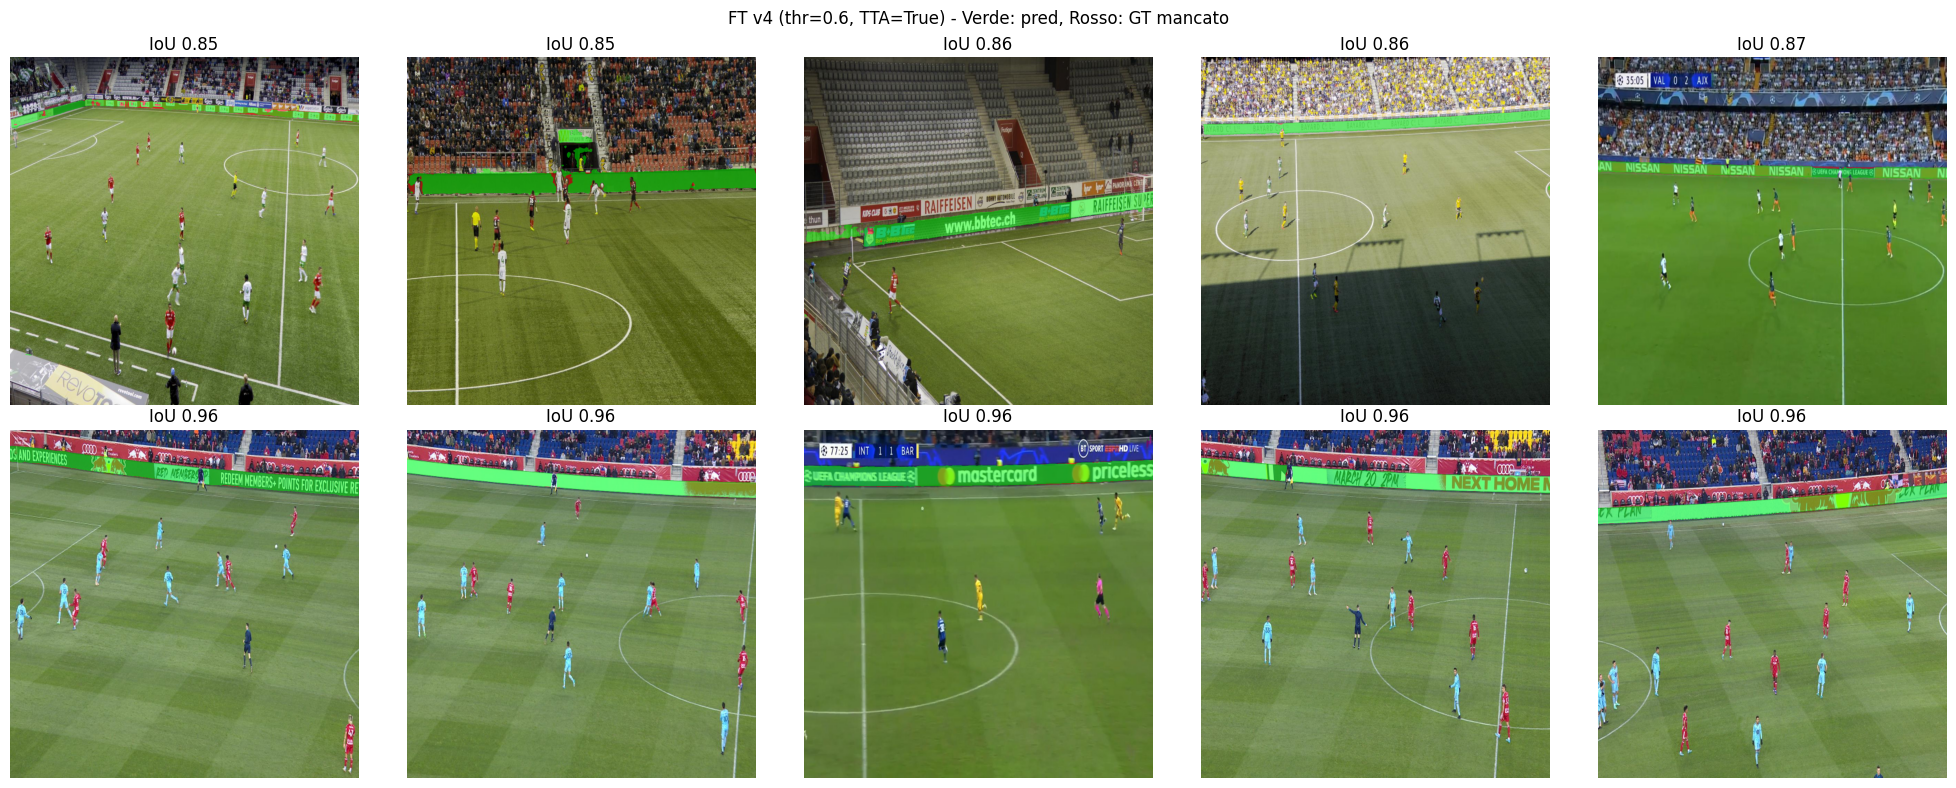

epoch,▁▁▁▂▂▂▂▃▃▃▃▃▃▃▃▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇█████
train/bce,█▂▁▂▁▂▂▂▂▄▁▂▃▁▂▂▁▁▁▂▁▂▁▁▁▂▁▁▁▁▁▁▁▁▁▂▁▁▁▁
train/epoch_loss,█▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/focal_tversky,▅▆█▄▃▂▁▃▂▂▂▇▂▄▂▂▁▄▂▁▂▂▂▁▃▁▁▁▂▁▁▁▂▁▁▁▂▂▁▁
train/loss,▄█▅▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/lr,▂██▇▇▇▇▇▇▇▇▆▆▆▆▆▆▅▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁
val/mIoU,▁▄▆▆▆▆▇▇███████████
best_threshold,0.6
best_val_miou,0.88255
epoch,19
test/IoU@0.5_ft,1



Run W&B chiuso. Dashboard: https://wandb.ai/


In [13]:
# Overlay qualitativi (5 peggiori + 5 migliori del FT) con best_thr
img_ids_list = coco_test.getImgIds()
order = np.argsort(ft_ious)
picks = list(order[:5]) + list(order[-5:])
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
overlay_imgs_for_wandb = []
for ax, idx in zip(axes.flat, picks):
    probs_ft, gt, fname = ft_probs_cache[idx]
    img = Image.open(test_dir / fname).convert('RGB')
    pred = probs_ft > best_thr
    overlay = np.array(img).copy()
    overlay[pred] = (0.5 * overlay[pred] + 0.5 * np.array([0, 255, 0])).astype(np.uint8)
    overlay[gt & ~pred] = (0.5 * overlay[gt & ~pred] + 0.5 * np.array([255, 0, 0])).astype(np.uint8)
    ax.imshow(overlay); ax.set_title(f'IoU {ft_ious[idx]:.2f}'); ax.axis('off')
    overlay_imgs_for_wandb.append(wandb.Image(overlay, caption=f'{fname} | IoU {ft_ious[idx]:.2f}'))
plt.suptitle(f"FT v4 (thr={best_thr}, TTA={CFG['use_tta']}) - Verde: pred, Rosso: GT mancato")
plt.tight_layout(); plt.show()

wandb.log({'test/overlays_best_thr': overlay_imgs_for_wandb})
wandb.finish()
print('\nRun W&B chiuso. Dashboard: https://wandb.ai/')
